# Applying SQD to PPP Hamiltonian for Polyacene: Problem Set

This notebook is the **problem-set** of SQD exercise set.
Refer to the tutorial if you have not gone through it yet.

To keep the live workflow manageable:
- the **base setup** below uses the **linear** polyacene example with `n_rings = 2`,
- **Problem 3** keeps the same linear-geometry PPP utility and treats `n_rings = 3` as a **real-backend target** rather than a local Statevector-sampling task.

> **Recommended workflow**
>
> - Debug new code first with the tutorial notebook (`n_rings = 1`).
> - Use the base setup in this notebook (`n_rings = 2`) for Problems 1, 2, and 4.
> - Run Problem 3 last.
> - In Problem 3, do the full local SQD workflow only for `n_rings = 2`.
> - For `n_rings = 3`, build the larger circuit and prepare it for a real backend; do not run local Statevector sampling for that case in this notebook.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np

warnings.filterwarnings("ignore")

HERE = Path.cwd().resolve()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from polyacene_ppp import build_polyacene_ppp, spinorb_ppp_to_spatial, plot_coordinate, plot_orbital_spread, plot_site_population
from ccsd_wrapper import run_ccsd_from_hg, transform_integrals_to_mo

### Base setup: linear polyacene with `n_rings = 2`

We first build the **linear** `n_rings = 2` PPP Hamiltonian, convert it to spatial-orbital tensors, and run RHF/CCSD.
These quantities are reused in Problems 1, 2, and 4.

Polyacene rings: 2
Spatial orbitals: 10
Spin orbitals / qubits: 20
Electrons (alpha, beta): (5, 5)
Constant intersite Coulomb shift: 231.548570 eV


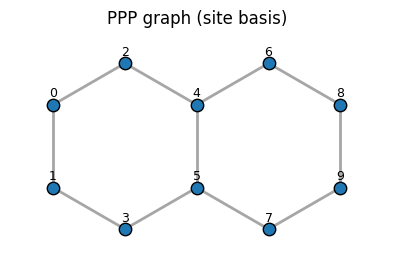

In [2]:
# PPP model parameters for the base problem-set case: linear n_rings = 2
n_rings = 2
t0 = -2.4          # eV
U = 11.26          # eV
bond_length = 1.4  # Angstrom
kappa = 1.0

ppp_spin = build_polyacene_ppp(
    n_rings=n_rings,
    t0=t0,
    U=U,
    bond_length=bond_length,
    kappa=kappa,
)

hcore_site, eri_site, energy_constant = spinorb_ppp_to_spatial(ppp_spin, U=U)

num_orbitals = hcore_site.shape[0]
num_elec_a = num_orbitals // 2
num_elec_b = num_orbitals // 2
nelec = (num_elec_a, num_elec_b)

print(f"Polyacene rings: {n_rings}")
print(f"Spatial orbitals: {num_orbitals}")
print(f"Spin orbitals / qubits: {2 * num_orbitals}")
print(f"Electrons (alpha, beta): {nelec}")
print(f"Constant intersite Coulomb shift: {energy_constant:.6f} eV")
plot_coordinate(ppp_spin)


### Run RHF and CCSD calculation


Next we run RHF/CCSD. The custom driver internally constructs an RHF reference from the supplied `hcore` and `eri` in the site basis, then solves CCSD on top of that reference. This gives us:

- the RHF energy,
- the CCSD energy,
- the CCSD amplitudes `t1` and `t2`, **(will be required for LUCJ ansatz initialization in the main problem)**
- the RHF orbital coefficient matrix `C`.

We then use `C` to rotate the Hamiltonian into the RHF orbital basis. Since the rotation is unitary, the exact Hamiltonian is unchanged; only its representation changes.


In [3]:
from pyscf.fci import direct_spin1

chemical_accuracy = 0.04336  # eV, equivalent to 1 kcal/mol, often used as a benchmark for "chemical accuracy" in quantum chemistry.

# Get RHF/CCSD data in the original site basis
ccsd_result = run_ccsd_from_hg(
    h=hcore_site,
    g=eri_site,
    nelec=sum(nelec),
    ecore=energy_constant,
    g_format="chemist",
    verbose=4, # adjust here if you don't want to see the detailed CCSD output.
)

hf_energy = ccsd_result["e_hf"]
ccsd_energy = ccsd_result["e_tot"]
t1 = ccsd_result["t1"]
t2 = ccsd_result["t2"]
mo_coeff = np.asarray(ccsd_result["mf"].mo_coeff, dtype=float)  # "mf" means mean-field (RHF) results.

# Rotate the full Hamiltonian into the RHF orbital basis
hcore_rhf, eri_rhf = transform_integrals_to_mo(hcore_site, eri_site, mo_coeff)

# Inspect how well the RHF orbital basis diagonalizes the mean-field Fock operator
fock_site = np.asarray(ccsd_result["mf"].get_fock(), dtype=float)
fock_rhf = mo_coeff.T @ fock_site @ mo_coeff
fock_offdiag_norm = np.linalg.norm(fock_rhf - np.diag(np.diag(fock_rhf)))

# Compute the FCI energy in the original site basis for reference
fci_energy, _ = direct_spin1.kernel(
    hcore_site,
    eri_site,
    num_orbitals,
    nelec,
    ecore=energy_constant,
)

print("\n=== RHF/CCSD Results ===")
print(f"RHF energy                     : {hf_energy:.6f} eV")
print(f"CCSD energy                    : {ccsd_energy:.6f} eV")
print(f"FCI energy                     : {fci_energy:.6f} eV")
print(f"Chemical accuracy threshold    : {chemical_accuracy:.6f} eV")
print(f"t1 shape                       : {t1.shape}")
print(f"t2 shape                       : {t2.shape}")
print(f"MO coefficient matrix shape    : {mo_coeff.shape}")
print(f"||offdiag(C^T F C)||_F         : {fock_offdiag_norm:.3e}")
print(f"||h_site||_F                   : {np.linalg.norm(hcore_site):.6f}")
print(f"||h_rhf||_F                    : {np.linalg.norm(hcore_rhf):.6f}")  # should be the same as h_site due to unitary transformation




******** <class 'pyscf.scf.hf.RHF'> ********
method = RHF
initial guess = 1e
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 200
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmpy60h6iaw
max_memory 4000 MB (current use 191 MB)
Set gradient conv threshold to 3.16228e-05
Initial guess from hcore.
  HOMO = -47.123984160996  LUMO = -45.3269335312375
init E= -8.53661462566137
  HOMO = 3.69137807826927  LUMO = 10.9065137446661
cycle= 1 E= -22.4432958646171  delta_E= -13.9  |g|= 1.88  |ddm|= 2.11
  HOMO = 1.25819466339118  LUMO = 10.1867541909096
cycle= 2 E= -22.5933252317874  delta_E= -0.15  |g|= 0.643  |ddm|= 0.171


Overwritten attributes  get_hcore get_ovlp  of <class 'pyscf.scf.hf.RHF'>


  HOMO = 1.17118329146347  LUMO = 10.0647066676206
cycle= 3 E= -22.6148498773611  delta_E= -0.0215  |g|= 0.067  |ddm|= 0.0882
  HOMO = 1.19031802895938  LUMO = 10.0720921231352
cycle= 4 E= -22.6151390087828  delta_E= -0.000289  |g|= 0.0145  |ddm|= 0.0107
  HOMO = 1.19021506542553  LUMO = 10.0693963714762
cycle= 5 E= -22.615154971781  delta_E= -1.6e-05  |g|= 0.00438  |ddm|= 0.00258
  HOMO = 1.19138229127827  LUMO = 10.0687046147831
cycle= 6 E= -22.6151567618609  delta_E= -1.79e-06  |g|= 0.00038  |ddm|= 0.00113
  HOMO = 1.19130331214563  LUMO = 10.0686864670292
cycle= 7 E= -22.6151567694507  delta_E= -7.59e-09  |g|= 0.000123  |ddm|= 7.91e-05
  HOMO = 1.19132315514523  LUMO = 10.0686763869119
cycle= 8 E= -22.615156770196  delta_E= -7.45e-10  |g|= 1.37e-05  |ddm|= 1.59e-05
  HOMO = 1.19132718742312  LUMO = 10.0686753660108
Extra cycle  E= -22.6151567702049  delta_E= -8.9e-12  |g|= 3.22e-06  |ddm|= 1.55e-06
converged SCF energy = -22.6151567702049
E(CCSD) = -23.9715573020122  E_corr = -1.35

## Problems

Now, based on the tutorial and references, solve and discuss the following problems by completing the code blocks.

### Problem 1. Build an LUCJ ansatz circuit from the CCSD amplitudes

**Goal.** Construct a **local unitary cluster Jastrow (LUCJ)** circuit initialized from the CCSD amplitudes obtained above.

**What you should do**

1. Use the RHF/CCSD amplitudes `t1` and `t2` computed in the base setup.
2. Use the **spin-balanced** LUCJ operator, because the reference state is closed shell.
3. Choose a hardware-friendly interaction pattern. In this reference solution, we use a heavy-hex-inspired sparse pattern:
   - nearest-neighbor pairs for same-spin interactions,
   - every fourth orbital for opposite-spin interactions.
4. Prepare the Hartree-Fock state in Jordan-Wigner ordering.
5. Append the LUCJ operator and add measurements.
6. Transpile the circuit targeting `ibm_yonsei` or any fake Heron backend such as `FakeFez`.
7. Report a few basic diagnostics such as circuit depth and gate counts.

**Deliverables**

- A quantum circuit acting on `2 * num_orbitals` qubits.
- A short explanation of how the interaction pairs were chosen.
- Circuit depth and two-qubit gate count.


In [4]:
# Reference solution for Problem 1

import ffsim
from qiskit import QuantumCircuit, QuantumRegister, generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeFez

n_reps = 1

# Heavy-hex-inspired sparse interaction pattern.
# The first list is reused for alpha-alpha and beta-beta interactions
# in the spin-balanced UCJ ansatz.

# TODO:
alpha_alpha_indices = 
alpha_beta_indices = 

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
    optimize=True,
    options=dict(maxiter=1000),
)

qubits = QuantumRegister(2 * num_orbitals, name="q")
lucj_circuit = QuantumCircuit(qubits)

# Prepare the Hartree-Fock determinant in Jordan-Wigner ordering.
lucj_circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)

# Apply the spin-balanced UCJ operator.
lucj_circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)

# Add measurements for bitstring sampling.
lucj_circuit.measure_all()

# Decompose the circuit and display (the barriers are just for visual separation of the layers).
lucj_circuit_decomposed = QuantumCircuit(*lucj_circuit.qregs, *lucj_circuit.cregs)
for instr in lucj_circuit.decompose().data:
    if instr.operation.name in ["measure", "barrier"]:
        continue
    lucj_circuit_decomposed.append(instr.operation, instr.qubits, instr.clbits)
    lucj_circuit_decomposed.barrier()
display(lucj_circuit_decomposed.draw("mpl", scale=0.5, fold=-1))

# Further decompose the circuit
display(lucj_circuit_decomposed.decompose().draw("mpl", scale=0.5, fold=22))


SyntaxError: invalid syntax (903907132.py, line 14)

In [ ]:
backend = FakeFez()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
lucj_t = pm.run(lucj_circuit)

print("=== LUCJ circuit summary ===")
print(f"n_reps                 : {n_reps}")
print(f"qubits                 : {lucj_t.num_qubits}")
print(f"depth                  : {lucj_t.depth()}")
print(f"size                   : {lucj_t.size()}")
print(f"same-spin pairs        : {len(alpha_alpha_indices)}")
print(f"opposite-spin pairs    : {len(alpha_beta_indices)}")
print(lucj_t.count_ops())

=== LUCJ circuit summary ===
n_reps                 : 1
qubits                 : 156
depth                  : 434
size                   : 4274
same-spin pairs        : 9
opposite-spin pairs    : 3
OrderedDict({'sx': 1872, 'rz': 1705, 'cz': 610, 'x': 67, 'measure': 20, 'barrier': 1})


### Problem 2. Estimate the ground-state energy using SQD and ansatz-generated samples

**Goal.** Replace the uniformly random bitstrings from the tutorial with samples obtained from
the LUCJ ansatz, and then run SQD on those samples.

**What you should do**

1. Generate bitstring samples from the circuit built in Problem 1.
2. Convert the raw counts to the bitstring/probability-array format used by
   `qiskit-addon-sqd`.
3. Run `diagonalize_fermionic_hamiltonian` on the **RHF-basis Hamiltonian**
   (`hcore_rhf`, `eri_rhf`), because the ansatz is defined relative to the RHF reference.
4. Use the Hartree-Fock occupations as the initial occupancy guess.
5. Track the iteration history and compare the final SQD energy against CCSD and, when
   affordable, FCI.

**Deliverables**

- A count dictionary or bitstring array generated from the ansatz circuit.
- An SQD energy estimate.
- A brief comparison to CCSD and optional FCI.


In [ ]:
# Reference solution for Problem 2

from functools import partial

from qiskit.primitives import StatevectorSampler
from qiskit_addon_sqd.fermion import SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch

# ---------------------------------------------------------------------
# 1) Sample bitstrings from the LUCJ circuit.
# For a local notebook demo, Statevector sampling is simple and robust.
# For hardware execution, replace this part with Sampler / Runtime counts.
# ---------------------------------------------------------------------
shots = 200_000
seed = 1234

rng = np.random.default_rng(seed)
sampler = StatevectorSampler(seed=rng)
job = sampler.run([lucj_circuit], shots=shots)
pub_result = job.result()[0]
bit_array = pub_result.data.meas
counts = bit_array.get_counts()
unique_bitstrings = list(counts.keys())

print("=== Sample summary ===")
print(f"shots                         : {shots}")
print(f"bit_array shape               : {bit_array.array.shape}")
print("number of unique bitstrings:", len(unique_bitstrings))
print(unique_bitstrings[:10])

=== Sample summary ===
shots                         : 200000
bit_array shape               : (200000, 3)
number of unique bitstrings: 2333
['01100101010000011111', '00000111110000011111', '01000101110000011111', '01000111010000011111', '00010111100000110111', '00010111100001010111', '00000111110001001111', '00000111110000111011', '00000111110100010111', '00100011110010001111']


In [ ]:
# ---------------------------------------------------------------------
# 2) Run SQD on the RHF-basis Hamiltonian.
# ---------------------------------------------------------------------
energy_tol = 1e-5
occupancies_tol = 1e-3
max_iterations = 5

num_batches = 3
samples_per_batch = 300
symmetrize_spin = True
carryover_threshold = 1e-4
max_cycle = 200

initial_occupancies = (
    np.array([1] * nelec[0] + [0] * (num_orbitals - nelec[0])),
    np.array([1] * nelec[1] + [0] * (num_orbitals - nelec[1])),
)

sci_solver = partial(solve_sci_batch, spin_sq=0.0, max_cycle=max_cycle)

ansatz_sqd_history = []

def ansatz_callback(results: list[SCIResult]):
    ansatz_sqd_history.append(results)
    iteration = len(ansatz_sqd_history)
    print(f"RHF-basis SQD | iteration {iteration}")
    for i, result in enumerate(results):
        print(f"    batch {i}")
        print(f"        Energy: {result.energy + energy_constant:.6f} eV")
        print(f"        Subspace dimension: {np.prod(result.sci_state.amplitudes.shape)}")

ansatz_sqd_result = diagonalize_fermionic_hamiltonian(
    hcore_rhf,
    eri_rhf,
    bit_array,
    samples_per_batch=samples_per_batch,
    norb=num_orbitals,
    nelec=nelec,
    num_batches=num_batches,
    energy_tol=energy_tol,
    occupancies_tol=occupancies_tol,
    max_iterations=max_iterations,
    sci_solver=sci_solver,
    symmetrize_spin=symmetrize_spin,
    initial_occupancies=initial_occupancies,
    carryover_threshold=carryover_threshold,
    callback=ansatz_callback,
    seed=np.random.default_rng(seed),
)

final_sqd_energy = ansatz_sqd_result.energy + energy_constant

print("\n=== Energy comparison ===")
print(f"HF energy                     : {hf_energy:.6f} eV")
print(f"CCSD energy                   : {ccsd_energy:.6f} eV")
print(f"Final SQD energy              : {final_sqd_energy:.6f} eV")
print(f"FCI energy                    : {fci_energy:.6f} eV")
print(f"SQD - FCI                     : {final_sqd_energy - fci_energy:+.6f} eV")
print(f"SQD - CCSD                    : {final_sqd_energy - ccsd_energy:+.6f} eV")

RHF-basis SQD | iteration 1
    batch 0
        Energy: -23.905538 eV
        Subspace dimension: 7056
    batch 1
        Energy: -23.911328 eV
        Subspace dimension: 7569
    batch 2
        Energy: -23.928956 eV
        Subspace dimension: 8100
RHF-basis SQD | iteration 2
    batch 0
        Energy: -23.954567 eV
        Subspace dimension: 11881
    batch 1
        Energy: -23.958211 eV
        Subspace dimension: 13689
    batch 2
        Energy: -23.958631 eV
        Subspace dimension: 11664
RHF-basis SQD | iteration 3
    batch 0
        Energy: -23.964310 eV
        Subspace dimension: 13689
    batch 1
        Energy: -23.963479 eV
        Subspace dimension: 13924
    batch 2
        Energy: -23.962338 eV
        Subspace dimension: 12996
RHF-basis SQD | iteration 4
    batch 0
        Energy: -23.971250 eV
        Subspace dimension: 15876
    batch 1
        Energy: -23.977100 eV
        Subspace dimension: 16129
    batch 2
        Energy: -23.978998 eV
        Subsp

### Problem 3. Compare the heavy-hex-inspired ansatz with a Nighthawk-style ansatz in the simulator

**Goal.** Investigate how a denser ansatz changes circuit cost and SQD quality.

In Problem 1, the LUCJ ansatz used a sparse interaction pattern motivated by a heavy-hex-like layout:
same-spin interactions were nearest-neighbor along the orbital chain, while opposite-spin interactions were included only at every fourth spatial orbital.
In this problem, compare that sparse ansatz against a **Nighthawk-style ansatz**, in which same-spin interactions remain nearest-neighbor, but opposite-spin interactions are included at **every** spatial orbital.

**What you should do**

1. Reuse the sparse heavy-hex-inspired LUCJ circuit from Problem 1.
2. Build a denser Nighthawk-style ansatz with:
   - nearest-neighbor same-spin pairs (`alpha_alpha_indices`)
   $$
   (p, p+1), \qquad 0 \le p < \texttt{norb} - 1,
   $$
   - and opposite-spin pairs at every spatial orbital (`alpha_beta_indices`)
   $$
   (p, p), \qquad 0 \le p < \texttt{norb}.
   $$
3. Transpile both circuits to the same hardware-like backend and compare:
   - circuit depth,
   - circuit size,
   - the number of same-spin and opposite-spin interaction pairs.
4. Generate simulator samples from both circuits and run SQD on the RHF-basis Hamiltonian.
5. Compare the final SQD energies against CCSD and discuss the tradeoff between expressivity and circuit cost.

**Deliverables**

- A Nighthawk-style LUCJ circuit construction.
- A direct comparison with the sparse heavy-hex-inspired circuit from Problem 1.
- A short discussion of whether the denser Nighthawk-style ansatz seems worthwhile in the simulator.

In [ ]:
# Reference solution for Problem 3

import pandas as pd
import matplotlib.pyplot as plt

import ffsim
from qiskit import QuantumCircuit, generate_preset_pass_manager
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_addon_sqd.fermion import diagonalize_fermionic_hamiltonian


def build_all_paired_lucj_circuit(num_orbitals, nelec, t1, t2, n_reps=1):
    """Build an LUCJ circuit with all same-spin and all opposite-spin interaction pairs."""

    
    alpha_alpha_indices = [(p, p + 1) for p in range(num_orbitals - 1)]
    alpha_beta_indices = [(p, p) for p in range(0, num_orbitals)]

    ucj_op_all = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=t2,
        t1=t1,
        n_reps=n_reps,
        interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
        optimize=True,
        options=dict(maxiter=1000),
    )

    qc_all = QuantumCircuit(2 * num_orbitals)
    qc_all.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), range(2 * num_orbitals))
    qc_all.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op_all), range(2 * num_orbitals))
    qc_all.measure_all()
    return qc_all, alpha_alpha_indices, alpha_beta_indices


def run_sqd_from_ansatz_samples(
    circuit,
    *,
    shots,
    seed,
    label,
):
    rng = np.random.default_rng(seed)
    sampler = StatevectorSampler(seed=rng)
    job = sampler.run([circuit], shots=shots)
    bit_array_local = job.result()[0].data.meas
    counts_local = bit_array_local.get_counts()

    sqd_result_local = diagonalize_fermionic_hamiltonian(
        hcore_rhf,
        eri_rhf,
        bit_array_local,
        samples_per_batch=300,
        norb=num_orbitals,
        nelec=nelec,
        num_batches=3,
        energy_tol=1e-5,
        occupancies_tol=1e-3,
        max_iterations=5,
        sci_solver=sci_solver,
        symmetrize_spin=True,
        initial_occupancies=initial_occupancies,
        carryover_threshold=1e-4,
        seed=np.random.default_rng(seed),
    )

    final_energy_local = sqd_result_local.energy + energy_constant
    print(f"{label} | unique samples : {len(counts_local)}")
    print(f"{label} | SQD energy     : {final_energy_local:.6f} eV")
    print(f"{label} | SQD - CCSD     : {final_energy_local - ccsd_energy:+.6f} eV")

    return final_energy_local, len(counts_local)


all_paired_circuit, all_same_spin_pairs, all_opposite_spin_pairs = build_all_paired_lucj_circuit(
    num_orbitals=num_orbitals,
    nelec=nelec,
    t1=t1,
    t2=t2,
    n_reps=1,
)

backend_problem3 = FakeFez()
pm_problem3 = generate_preset_pass_manager(backend=backend_problem3, optimization_level=3)
lucj_t_sparse = pm_problem3.run(lucj_circuit)
lucj_t_all = pm_problem3.run(all_paired_circuit)

shots_problem3 = 100_000
sparse_sqd_energy, sparse_unique_samples = run_sqd_from_ansatz_samples(
    lucj_circuit,
    shots=shots_problem3,
    seed=1234,
    label="Sparse heavy-hex-inspired ansatz",
)
all_sqd_energy, all_unique_samples = run_sqd_from_ansatz_samples(
    all_paired_circuit,
    shots=shots_problem3,
    seed=1234,
    label="Nighthawk's all-paired spin ansatz",
)

problem3_compare_df = pd.DataFrame(
    [
        {
            "ansatz": "Sparse heavy-hex-inspired",
            "depth": lucj_t_sparse.depth(),
            "size": lucj_t_sparse.size(),
            "qubits": lucj_t_sparse.num_qubits,
            "same_spin_pairs": len(alpha_alpha_indices),
            "opposite_spin_pairs": len(alpha_beta_indices),
            "unique_samples": sparse_unique_samples,
            "sqd_energy": sparse_sqd_energy,
            "sqd_minus_ccsd": sparse_sqd_energy - ccsd_energy,
        },
        {
            "ansatz": "Nighthawk's all-paired spin",
            "depth": lucj_t_all.depth(),
            "size": lucj_t_all.size(),
            "qubits": lucj_t_all.num_qubits,
            "same_spin_pairs": len(all_same_spin_pairs),
            "opposite_spin_pairs": len(all_opposite_spin_pairs),
            "unique_samples": all_unique_samples,
            "sqd_energy": all_sqd_energy,
            "sqd_minus_ccsd": all_sqd_energy - ccsd_energy,
        },
    ]
)

print("\n=== Problem 3 comparison summary ===")
display(problem3_compare_df)


Sparse heavy-hex-inspired ansatz | unique samples : 1649
Sparse heavy-hex-inspired ansatz | SQD energy     : -23.988220 eV
Sparse heavy-hex-inspired ansatz | SQD - CCSD     : -0.016663 eV
Nighthawk's all-paired spin ansatz | unique samples : 1312
Nighthawk's all-paired spin ansatz | SQD energy     : -23.983484 eV
Nighthawk's all-paired spin ansatz | SQD - CCSD     : -0.011927 eV

=== Problem 3 comparison summary ===


,ansatz,depth,size,qubits,same_spin_pairs,opposite_spin_pairs,unique_samples,sqd_energy,sqd_minus_ccsd
0,Sparse heavy-hex-inspired,518,4318,156,9,3,1649,-23.988220,-0.016663
1,Nighthawk's all-paired spin,656,4594,156,9,10,1312,-23.983484,-0.011927


### Problem 4. (Advanced) Scale up to linear `n_rings = 3`, but reserve sampling for a real backend

**Goal.** Integrate the workflow to scale up to the real-backend utility.

In this notebook, use the same **linear polyacene** PPP utility throughout.
In thie problem, prepare the larger `n_rings = 3` case for a real backend.

**What you should do**

1. Build the PPP → RHF/CCSD → LUCJ construction workflow for the `n_rings = 3` case using the same PPP parameter setting, and compute at least:
   - the RHF energy,
   - the CCSD energy,
   - the ansatz circuit size/depth after transpilation to a hardware-like backend.
2. If you have access to a real backend, collect samples for the `n_rings = 3` circuit there and then run SQD on those hardware samples.

**Practical note.** Do not run local `StatevectorSampler` sampling for `n_rings = 3` in this notebook, it takes too much memory and time.


In [ ]:
# Reference solution for Problem 4

import numpy as np
import pandas as pd
from functools import partial

import ffsim
from qiskit import QuantumCircuit, generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_addon_sqd.fermion import SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch

from polyacene_ppp import build_polyacene_ppp, spinorb_ppp_to_spatial
from ccsd_wrapper import run_ccsd_from_hg, transform_integrals_to_mo


def build_lucj_circuit_from_ccsd_for_case(num_orbitals, nelec, t1, t2, n_reps=1):
    """Build the same sparse LUCJ ansatz pattern used in Problem 1."""
    alpha_alpha_indices = [(p, p + 1) for p in range(num_orbitals - 1)]
    alpha_beta_indices = [(p, p) for p in range(0, num_orbitals, 4)]

    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=t2,
        t1=t1,
        n_reps=n_reps,
        interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
        optimize=True,
        options=dict(maxiter=1000),
    )

    qc = QuantumCircuit(2 * num_orbitals)
    qc.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), range(2 * num_orbitals))
    qc.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), range(2 * num_orbitals))
    qc.measure_all()
    return qc, alpha_alpha_indices, alpha_beta_indices


def prepare_problem4_case(
    *,
    case_label,
    n_rings,
    t0=-2.4,
    U=11.26,
    bond_length=1.4,
    kappa=1.0,
):
    """Build the linear PPP model, run RHF/CCSD, and construct the LUCJ circuit."""

    ppp_spin_local = build_polyacene_ppp(
        n_rings=n_rings,
        t0=t0,
        U=U,
        bond_length=bond_length,
        kappa=kappa,
    )
    hcore_site_local, eri_site_local, energy_constant_local = spinorb_ppp_to_spatial(ppp_spin_local, U=U)

    num_orbitals_local = hcore_site_local.shape[0]
    nelec_local = (num_orbitals_local // 2, num_orbitals_local // 2)

    ccsd_result_local = run_ccsd_from_hg(
        h=hcore_site_local,
        g=eri_site_local,
        nelec=sum(nelec_local),
        ecore=energy_constant_local,
        g_format="chemist",
        verbose=0,
    )
    hf_energy_local = ccsd_result_local["e_hf"]
    ccsd_energy_local = ccsd_result_local["e_tot"]
    t1_local = ccsd_result_local["t1"]
    t2_local = ccsd_result_local["t2"]
    mo_coeff_local = np.asarray(ccsd_result_local["mf"].mo_coeff, dtype=float)

    hcore_rhf_local, eri_rhf_local = transform_integrals_to_mo(
        hcore_site_local, eri_site_local, mo_coeff_local
    )

    lucj_circuit_local, alpha_alpha_local, alpha_beta_local = build_lucj_circuit_from_ccsd_for_case(
        num_orbitals_local, nelec_local, t1_local, t2_local, n_reps=1
    )

    return {
        "case": case_label,
        "n_rings": n_rings,
        "ppp_spin": ppp_spin_local,
        "hcore_site": hcore_site_local,
        "eri_site": eri_site_local,
        "hcore_rhf": hcore_rhf_local,
        "eri_rhf": eri_rhf_local,
        "energy_constant": energy_constant_local,
        "num_orbitals": num_orbitals_local,
        "nelec": nelec_local,
        "hf_energy": hf_energy_local,
        "ccsd_energy": ccsd_energy_local,
        "lucj_circuit": lucj_circuit_local,
        "same_spin_pairs": alpha_alpha_local,
        "opposite_spin_pairs": alpha_beta_local,
    }


def run_sqd_from_hardware_samples(
    prepared_case,
    bit_array_hw,
    *,
    samples_per_batch=200,
    num_batches=2,
    max_iterations=4,
    seed=1234,
):
    """Run SQD from real-backend samples collected elsewhere."""

    num_orbitals_local = prepared_case["num_orbitals"]
    nelec_local = prepared_case["nelec"]
    energy_constant_local = prepared_case["energy_constant"]

    initial_occupancies_local = (
        np.array([1] * nelec_local[0] + [0] * (num_orbitals_local - nelec_local[0])),
        np.array([1] * nelec_local[1] + [0] * (num_orbitals_local - nelec_local[1])),
    )

    sqd_history_local = []

    def callback_local(results: list[SCIResult]):
        sqd_history_local.append(results)
        iteration = len(sqd_history_local)
        print(f"{prepared_case['case']} | SQD iteration {iteration}")
        for i, result in enumerate(results):
            print(f"    batch {i}")
            print(f"        Energy: {result.energy + energy_constant_local:.6f} eV")
            print(f"        Subspace dimension: {np.prod(result.sci_state.amplitudes.shape)}")

    sci_solver_local = partial(solve_sci_batch, spin_sq=0.0, max_cycle=200)

    sqd_result_local = diagonalize_fermionic_hamiltonian(
        prepared_case["hcore_rhf"],
        prepared_case["eri_rhf"],
        bit_array_hw,
        samples_per_batch=samples_per_batch,
        norb=num_orbitals_local,
        nelec=nelec_local,
        num_batches=num_batches,
        energy_tol=1e-5,
        occupancies_tol=1e-3,
        max_iterations=max_iterations,
        sci_solver=sci_solver_local,
        symmetrize_spin=True,
        initial_occupancies=initial_occupancies_local,
        carryover_threshold=1e-4,
        callback=callback_local,
        seed=np.random.default_rng(seed),
    )

    counts_hw = bit_array_hw.get_counts()
    return {
        "case": prepared_case["case"],
        "n_rings": prepared_case["n_rings"],
        "mode": "hardware SQD",
        "hf_energy": prepared_case["hf_energy"],
        "ccsd_energy": prepared_case["ccsd_energy"],
        "sqd_energy": sqd_result_local.energy + energy_constant_local,
        "hf_minus_ccsd": prepared_case["hf_energy"] - prepared_case["ccsd_energy"],
        "sqd_minus_ccsd": sqd_result_local.energy + energy_constant_local - prepared_case["ccsd_energy"],
        "qubits": 2 * num_orbitals_local,
        "unique_samples": len(counts_hw),
        "same_spin_pairs": len(prepared_case["same_spin_pairs"]),
        "opposite_spin_pairs": len(prepared_case["opposite_spin_pairs"]),
    }


# ------------------------------------------------------------------
# Problem 4: linear n_rings = 3 only
# Prepare the workflow and transpile the ansatz for a hardware-like backend.
# Do not run local Statevector sampling here.
# ------------------------------------------------------------------
problem4_case_n3 = prepare_problem4_case(
    case_label="linear n_rings = 3 (real-backend target)",
    n_rings=3,
)

# Replace `FakeFez()` by your real backend when available.
backend_for_problem4_n3 = FakeFez()
pm_problem4_n3 = generate_preset_pass_manager(
    backend=backend_for_problem4_n3,
    optimization_level=3,
)
lucj_t_n3 = pm_problem4_n3.run(problem4_case_n3["lucj_circuit"])

problem4_n3_row = {
    "case": problem4_case_n3["case"],
    "n_rings": problem4_case_n3["n_rings"],
    "mode": "prepare/transpile only",
    "hf_energy": problem4_case_n3["hf_energy"],
    "ccsd_energy": problem4_case_n3["ccsd_energy"],
    "sqd_energy": np.nan,
    "hf_minus_ccsd": problem4_case_n3["hf_energy"] - problem4_case_n3["ccsd_energy"],
    "sqd_minus_ccsd": np.nan,
    "qubits": lucj_t_n3.num_qubits,
    "depth": lucj_t_n3.depth(),
    "size": lucj_t_n3.size(),
    "same_spin_pairs": len(problem4_case_n3["same_spin_pairs"]),
    "opposite_spin_pairs": len(problem4_case_n3["opposite_spin_pairs"]),
}

print("=== n_rings = 3 hardware-target circuit summary ===")
print(f"qubits                 : {problem4_n3_row['qubits']}")
print(f"depth                  : {problem4_n3_row['depth']}")
print(f"size                   : {problem4_n3_row['size']}")
print(f"same-spin pairs        : {problem4_n3_row['same_spin_pairs']}")
print(f"opposite-spin pairs    : {problem4_n3_row['opposite_spin_pairs']}")
print(f"RHF energy             : {problem4_n3_row['hf_energy']:.6f} eV")
print(f"CCSD energy            : {problem4_n3_row['ccsd_energy']:.6f} eV")
print("SQD energy             : provide real-backend samples, then rerun SQD on those samples")

problem4_df = pd.DataFrame([problem4_n3_row])
display(problem4_df)

# ------------------------------------------------------------------
# Optional: after collecting real-backend samples, run SQD on them.
# Here `bit_array_hw` should be the measurement result object returned by
# the backend sampler job, analogous to `job.result()[0].data.meas`.
# ------------------------------------------------------------------
# from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
# 
# service = QiskitRuntimeService()
# backend = service.backend("...")
# sampler = Sampler(mode=backend)

# job = sampler.run([lucj_t_n3], shots=shots)
# result = job.result()
# bit_array_hw = result[0].data.meas
# problem4_hw_row = run_sqd_from_hardware_samples(
#     problem4_case_n3,
#     bit_array_hw,
#     samples_per_batch=200,
#     num_batches=2,
#     max_iterations=4,
#     seed=1234,
# )
# display(pd.DataFrame([problem4_hw_row]))

E(CCSD) = -33.79849472784359  E_corr = -1.981497964615456
=== n_rings = 3 hardware-target circuit summary ===
qubits                 : 156
depth                  : 965
size                   : 8932
same-spin pairs        : 13
opposite-spin pairs    : 4
RHF energy             : -31.816997 eV
CCSD energy            : -33.798495 eV
SQD energy             : provide real-backend samples, then rerun SQD on those samples


,case,n_rings,mode,hf_energy,ccsd_energy,sqd_energy,hf_minus_ccsd,sqd_minus_ccsd,qubits,depth,size,same_spin_pairs,opposite_spin_pairs
0,linear n_rings = 3 (real-backend target),3,prepare/transpile only,-31.816997,-33.798495,NaN,1.981498,NaN,156,965,8932,13,4
